<a href="https://colab.research.google.com/github/Samujjalborah/python-learning-journey/blob/main/IDRAfinal/Final_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Table of Contents

1. Introduction
2. Problem Statement
3. Dataset Overview
4. Data Cleaning
5. Exploratory Data Analysis
6. Statistical Analysis
7. Data Preprocessing
8. Logistic Regression Model
9. Decision Tree Model
10. Model Comparison
11. Feature Importance
12. Key Findings
13. Recommendations
14. Conclusion

# Employee Attrition and Workforce Analytics
## Final Capstone Project

### Objective

The objective of this project is to analyze employee attrition using workforce data and develop machine learning models that predict whether an employee is likely to leave the organization. The project follows a complete data science workflow including data cleaning, exploratory data analysis (EDA), statistical analysis, feature engineering, model development, evaluation, and business recommendations.

Developed by: Samujjal Borah

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("employee_attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("FIRST FIVE RECORDS")
print("="*60)

display(df.head())

print("\n")

print("="*60)
print("DATA TYPES")
print("="*60)

display(df.dtypes)

print("\n")

print("="*60)
print("MISSING VALUES")
print("="*60)

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

display(missing[missing["Missing Values"]>0])

print("\n")

print("="*60)
print("DUPLICATE RECORDS")
print("="*60)

print(df.duplicated().sum())

DATASET SHAPE
(1470, 35)


FIRST FIVE RECORDS


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2




DATA TYPES


,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64




MISSING VALUES


,Missing Values,Percentage




DUPLICATE RECORDS
0


# Data Cleaning

The dataset was inspected for missing values, duplicate records, and incorrect data types before analysis.

### Cleaning Summary

- Missing Values: None
- Duplicate Records: None
- Data Types: Correct
- Dataset is ready for exploratory data analysis.

In [5]:

df_clean = df.copy()

print("Dataset Shape:", df_clean.shape)

Dataset Shape: (1470, 35)


#Separate Numerical & Categorical Variables

In [6]:
numerical_cols = df_clean.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)

Numerical Columns
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


#Descriptive Statistics

In [7]:
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

display(df_clean[numerical_cols].describe())

DESCRIPTIVE STATISTICS


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


#Exploratory Data Analysis (EDA)

1. Attrition Distribution

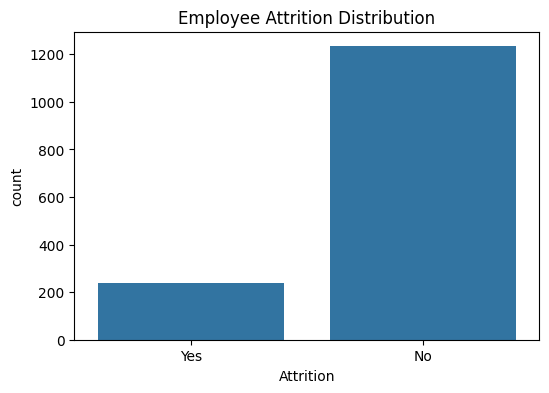

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.show()

2. Age Distribution

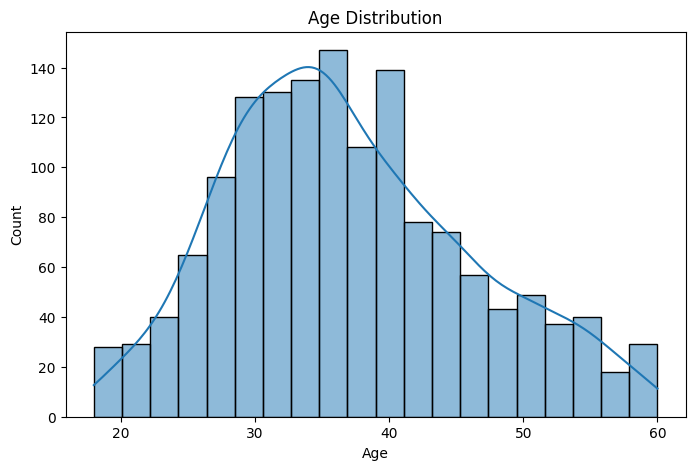

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

3. Department-wise Attrition

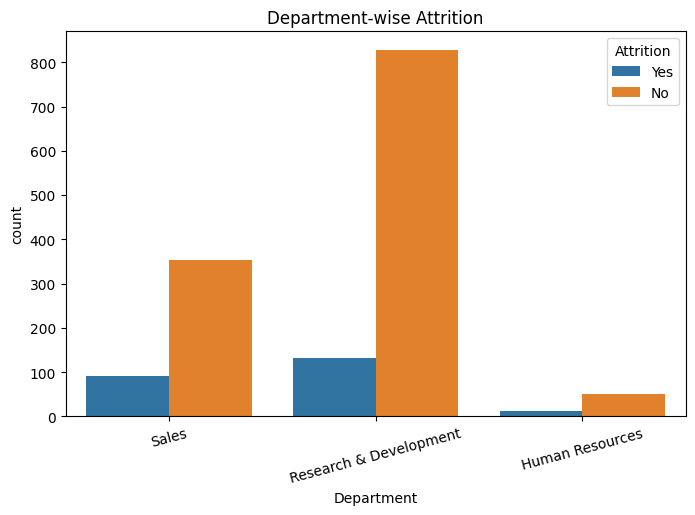

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean,
              x="Department",
              hue="Attrition")

plt.xticks(rotation=15)
plt.title("Department-wise Attrition")
plt.show()

4. Monthly Income vs Attrition

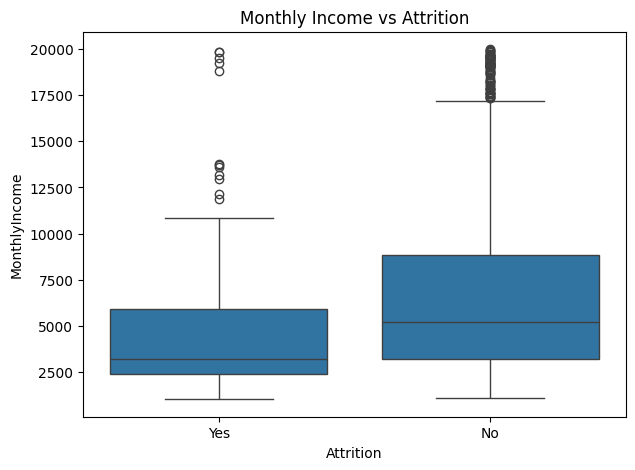

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_clean,
            x="Attrition",
            y="MonthlyIncome")

plt.title("Monthly Income vs Attrition")
plt.show()

5. Overtime vs Attrition

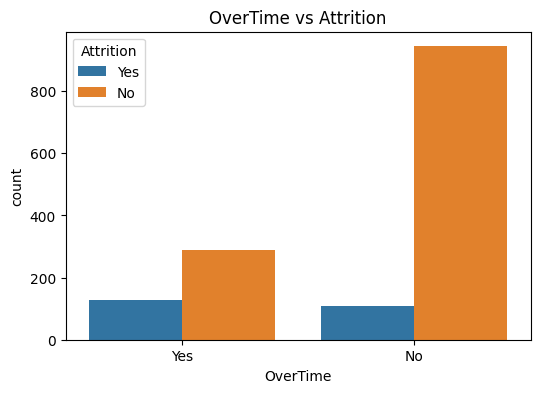

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean,
              x="OverTime",
              hue="Attrition")

plt.title("OverTime vs Attrition")
plt.show()

6. Job Satisfaction vs Attrition

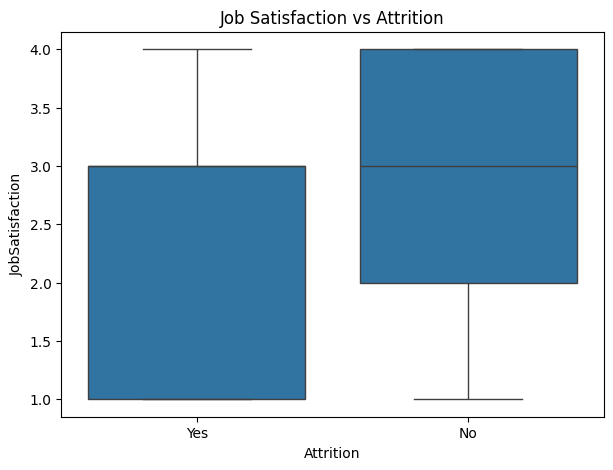

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_clean,
            x="Attrition",
            y="JobSatisfaction")

plt.title("Job Satisfaction vs Attrition")
plt.show()

7. Correlation Heatmap

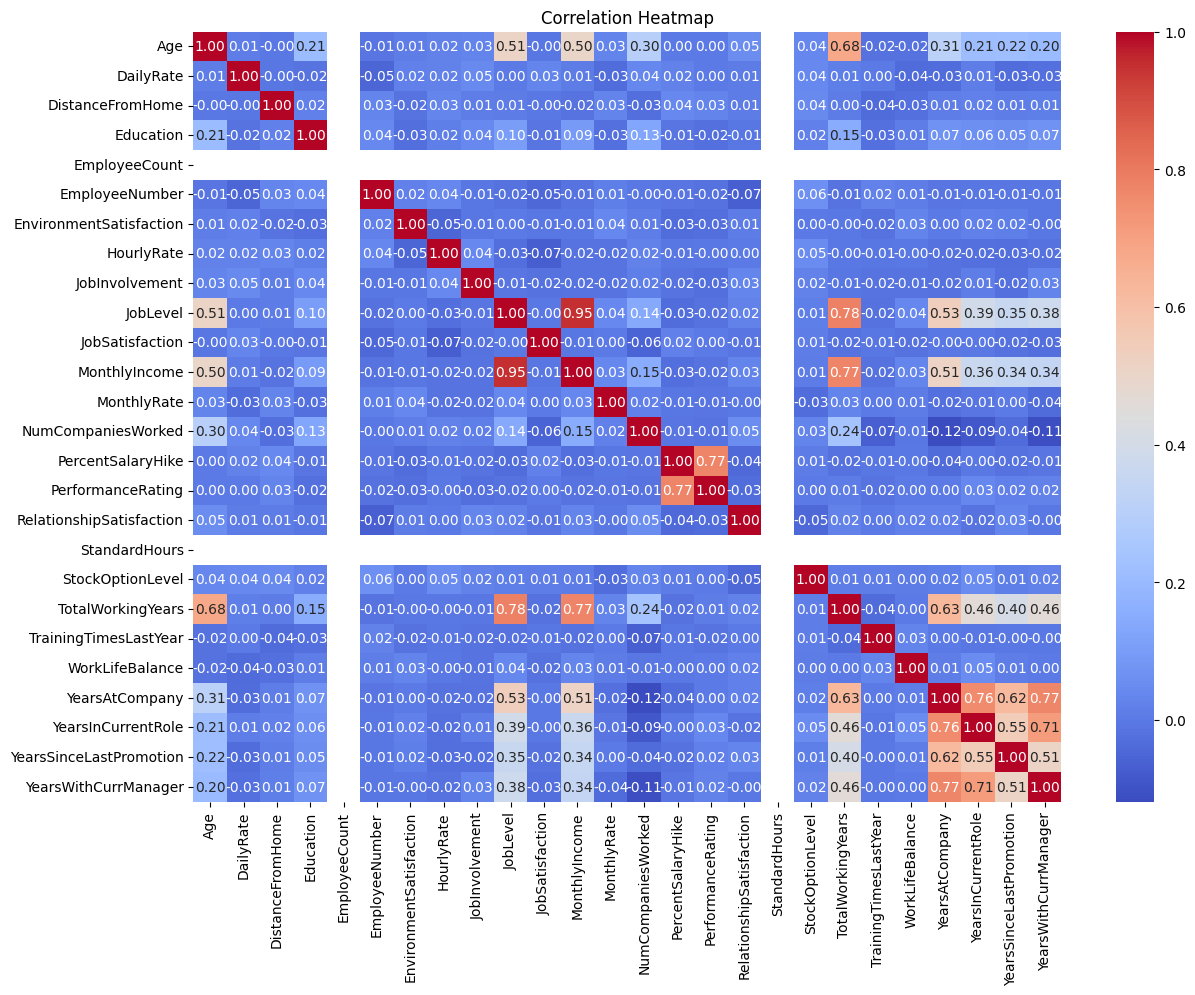

In [14]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_clean[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

8. Boxplot of Numerical Variables

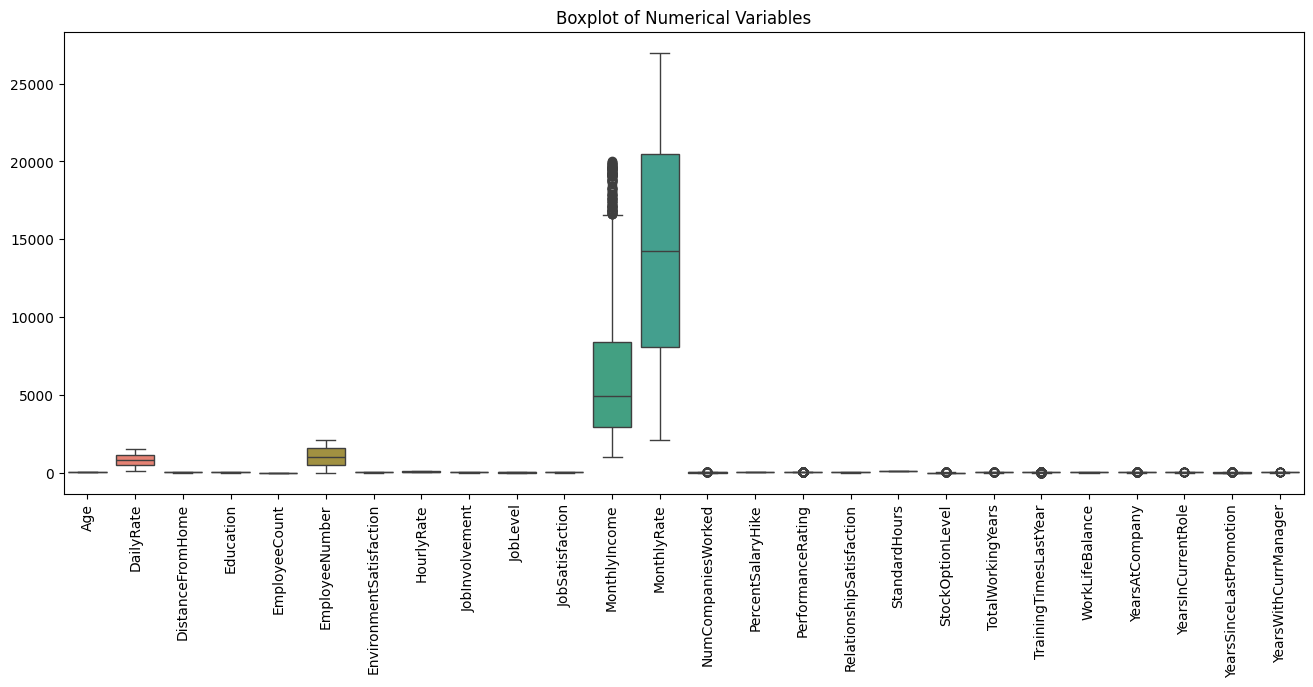

In [15]:
plt.figure(figsize=(16,6))

sns.boxplot(data=df_clean[numerical_cols])

plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Variables")

plt.show()

9. Business Travel vs Attrition

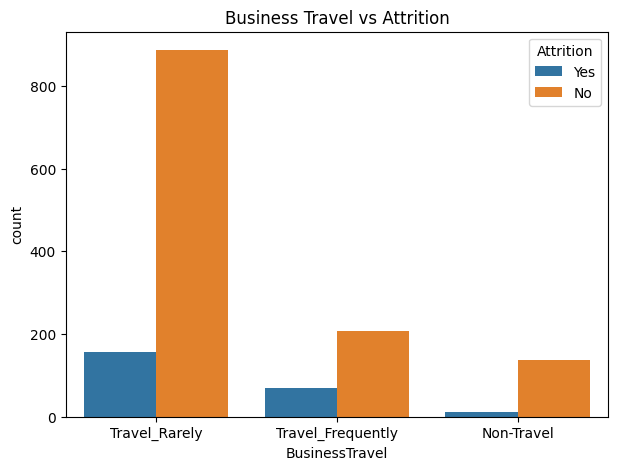

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="BusinessTravel",
    hue="Attrition"
)

plt.title("Business Travel vs Attrition")

plt.show()

10. Work-Life Balance vs Attrition

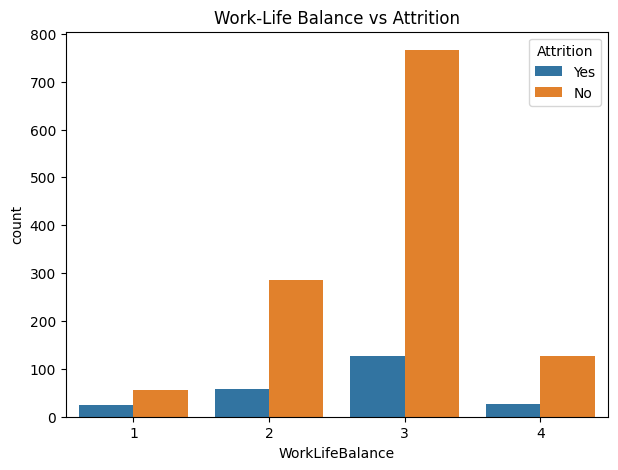

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance vs Attrition")

plt.show()

# EDA Interpretation

### Key Findings

- The dataset contains 1,470 employee records with 35 variables and no missing values or duplicate records, indicating excellent data quality.

- Employee attrition is imbalanced, with substantially more employees staying than leaving the organization.

- Most employees are between 30 and 40 years of age.

- Employees working overtime appear to have a higher proportion of attrition compared to those who do not work overtime.

- Employees with lower monthly income appear more likely to leave the organization.

- Research & Development has the largest workforce and therefore records the highest number of attrition cases.

- Employees with lower job satisfaction show relatively higher attrition.

- Business travel frequency appears to have some relationship with employee attrition.

- The correlation heatmap shows strong positive relationships between:
    - Job Level and Monthly Income
    - Total Working Years and Monthly Income
    - Years at Company and Years with Current Manager

- Several variables contain outliers, particularly Monthly Income and Employee Number, but these are expected in real-world HR datasets and are retained.

# Statistical Analysis

Descriptive statistics were calculated to summarize the numerical variables.

The mean, standard deviation, minimum, maximum and quartiles provide insight into employee demographics, salaries, experience and satisfaction levels.

These statistics help understand the spread and central tendency before developing machine learning models.

In [18]:
display(df_clean[numerical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


#Machine Learning Preparation

In [19]:
from sklearn.preprocessing import LabelEncoder

df_ml = df_clean.copy()

label = LabelEncoder()

for col in df_ml.select_dtypes(include="object"):
    df_ml[col] = label.fit_transform(df_ml[col])

df_ml.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


#Correlation with Target

In [20]:
corr = df_ml.corr()["Attrition"].sort_values(ascending=False)

display(corr)

,Attrition
Attrition,1.000000
OverTime,0.246118
MaritalStatus,0.162070
DistanceFromHome,0.077924
JobRole,0.067151
Department,0.063991
NumCompaniesWorked,0.043494
Gender,0.029453
EducationField,0.026846
MonthlyRate,0.015170


### Variables Most Related to Employee Attrition

The correlation analysis shows that **OverTime** has the strongest positive relationship with employee attrition (0.246), suggesting that employees who work overtime are more likely to leave the organization.

Other variables showing a positive relationship include **Marital Status**, **Distance From Home**, and **Number of Companies Worked**, although their correlations are relatively weak.

Several variables have negative correlations with attrition, indicating that employees are generally less likely to leave as these values increase. The strongest negative correlations are observed for:

- Total Working Years (-0.171)
- Job Level (-0.169)
- Years in Current Role (-0.161)
- Monthly Income (-0.160)
- Age (-0.159)
- Years with Current Manager (-0.156)

Overall, no single variable has an extremely strong correlation with attrition, suggesting that employee turnover is influenced by multiple factors rather than one individual feature. These variables are therefore used collectively for machine learning model development.

In [21]:
df_ml = df_ml.drop(columns=[
    "EmployeeCount",
    "StandardHours",
    "Over18"
])

#Define Features and Target

In [22]:
# Features
X = df_ml.drop("Attrition", axis=1)

# Target
y = df_ml["Attrition"]

#Train Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (1176, 31)
Testing Shape  : (294, 31)


#Feature Scaling

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

#Evaluate Logistic Regression

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)

print("Accuracy :", round(accuracy_score(y_test, y_pred_lr),3))
print("Precision:", round(precision_score(y_test, y_pred_lr),3))
print("Recall   :", round(recall_score(y_test, y_pred_lr),3))
print("F1-score :", round(f1_score(y_test, y_pred_lr),3))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy : 0.874
Precision: 0.692
Recall   : 0.383
F1-score : 0.493

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



#Confusion Matrix

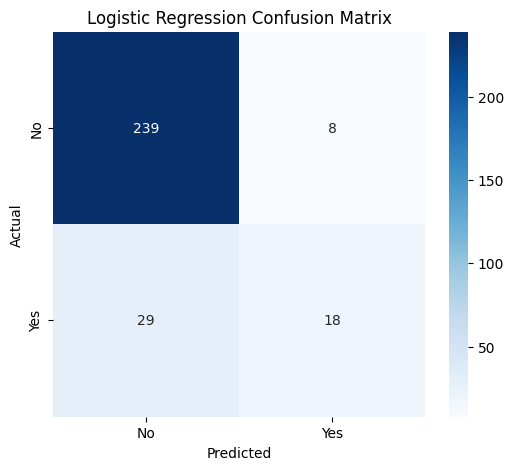

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No","Yes"],
    yticklabels=["No","Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

## Logistic Regression Interpretation

- The Logistic Regression model achieved an overall accuracy of **87.4%**, indicating good overall prediction performance.
- The model produced a precision of **69.2%**, meaning that when it predicted an employee would leave, the prediction was correct about 69% of the time.
- The recall was **38.3%**, showing that many employees who actually left were not identified by the model.
- The F1-score of **49.3%** reflects the balance between precision and recall and suggests moderate performance for predicting employee attrition.
- The confusion matrix shows that the model correctly predicted **239 employees who stayed** and **18 employees who left**, while misclassifying **37 employees**.
- Because the dataset is imbalanced (many more employees stayed than left), Logistic Regression favors the majority class, resulting in lower recall for attrition cases.

#Decision Tree Classifier

In [28]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

#Decision Tree Evaluation

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("="*60)
print("DECISION TREE RESULTS")
print("="*60)

print("Accuracy :", round(accuracy_score(y_test,y_pred_dt),3))
print("Precision:", round(precision_score(y_test,y_pred_dt),3))
print("Recall   :", round(recall_score(y_test,y_pred_dt),3))
print("F1-score :", round(f1_score(y_test,y_pred_dt),3))

print("\nClassification Report")
print(classification_report(y_test,y_pred_dt))

DECISION TREE RESULTS
Accuracy : 0.84
Precision: 0.5
Recall   : 0.191
F1-score : 0.277

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.50      0.19      0.28        47

    accuracy                           0.84       294
   macro avg       0.68      0.58      0.59       294
weighted avg       0.80      0.84      0.81       294



#Decision Tree Confusion Matrix

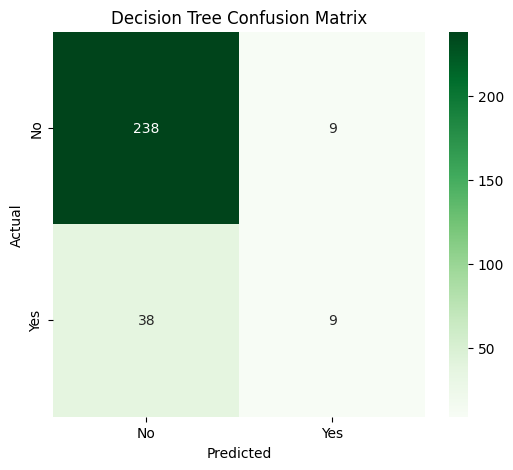

In [30]:
cm = confusion_matrix(y_test,y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No","Yes"],
    yticklabels=["No","Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

## Decision Tree Interpretation

- The Decision Tree model achieved an overall accuracy of **84.0%**.
- The precision of **50.0%** indicates that only half of the employees predicted to leave actually left.
- The recall of **19.1%** is relatively low, meaning the model identified only a small portion of employees who actually left the company.
- The F1-score of **27.7%** indicates weaker performance compared to Logistic Regression.
- The confusion matrix shows that the model correctly predicted **238 employees who stayed** and **9 employees who left**, but failed to identify **38 employees who actually left**.
- Overall, the Decision Tree tends to favor the majority class and is less effective for detecting employee attrition.

# Model Comparison

In [31]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree"],
    "Accuracy":[0.874,0.840],
    "Precision":[0.692,0.500],
    "Recall":[0.383,0.191],
    "F1-score":[0.493,0.277]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.874,0.692,0.383,0.493
1,Decision Tree,0.840,0.500,0.191,0.277


## Model Comparison Interpretation

| Metric | Logistic Regression | Decision Tree | Better Model |
|--------|--------------------:|--------------:|:------------|
| Accuracy | 87.4% | 84.0% | Logistic Regression |
| Precision | 69.2% | 50.0% | Logistic Regression |
| Recall | 38.3% | 19.1% | Logistic Regression |
| F1-score | 49.3% | 27.7% | Logistic Regression |

### Interpretation

- Logistic Regression achieved better performance than the Decision Tree across all evaluation metrics.
- Logistic Regression obtained the highest accuracy (**87.4%**) and produced more reliable predictions for employee attrition.
- The Decision Tree model showed lower precision, recall, and F1-score, indicating that it struggled to correctly identify employees who left the company.
- Logistic Regression is therefore selected as the preferred model for predicting employee attrition in this project.

#Important Features

In [34]:
importance = pd.Series(
    np.abs(lr.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

importance.head(10)

,0
OverTime,0.782163
YearsSinceLastPromotion,0.481498
Department,0.470444
NumCompaniesWorked,0.449615
YearsWithCurrManager,0.437533
EnvironmentSatisfaction,0.437171
TotalWorkingYears,0.418747
Age,0.410156
JobSatisfaction,0.381713
YearsInCurrentRole,0.359704


# Feature Importance Interpretation

The Logistic Regression model identified the following variables as the most influential predictors of employee attrition:

| Feature | Importance |
|---------|-----------:|
| OverTime | 0.782 |
| YearsSinceLastPromotion | 0.481 |
| Department | 0.470 |
| NumCompaniesWorked | 0.450 |
| YearsWithCurrManager | 0.438 |
| EnvironmentSatisfaction | 0.437 |
| TotalWorkingYears | 0.419 |
| Age | 0.410 |
| JobSatisfaction | 0.382 |
| YearsInCurrentRole | 0.360 |

### Interpretation

- **OverTime** was the strongest predictor of employee attrition, indicating that employees working overtime are more likely to leave the organization.
- Employees who had gone longer without a promotion showed a higher likelihood of attrition.
- Work-related factors such as **Department**, **Years with Current Manager**, and **Job Satisfaction** also influenced employee retention.
- Experience-related variables including **Total Working Years**, **Years in Current Role**, and **Number of Companies Worked** played an important role in predicting employee turnover.
- These findings suggest that workload, career growth opportunities, and workplace satisfaction are major drivers of employee attrition.

# Key Findings

1. The dataset was clean, with **no missing values and no duplicate records**, allowing reliable analysis and model development.

2. Exploratory Data Analysis showed that **employees working overtime were more likely to leave the organization**, making overtime an important factor associated with attrition.

3. Logistic Regression outperformed the Decision Tree model, achieving:
   - Accuracy: **87.4%**
   - Precision: **69.2%**
   - Recall: **38.3%**
   - F1-score: **49.3%**

4. Feature importance analysis identified **OverTime**, **Years Since Last Promotion**, **Department**, **Number of Companies Worked**, and **Years with Current Manager** as the most influential predictors of employee attrition.

5. Employee attrition appears to be influenced by multiple workplace factors rather than a single variable, highlighting the importance of using machine learning for workforce analytics.

# Recommendations

Based on the analysis, the following recommendations are suggested:

1. Reduce excessive overtime by improving workload distribution and workforce planning.

2. Review promotion policies to ensure employees receive timely career growth opportunities and reduce dissatisfaction caused by long promotion gaps.

3. Strengthen employee engagement programs within departments experiencing higher attrition.

4. Improve manager–employee communication and support, especially for employees who have spent several years with the same manager.

5. Develop targeted retention strategies for employees with multiple previous employers, as they may have a higher tendency to leave.

6. Use predictive analytics models such as Logistic Regression to identify employees at risk of attrition and implement proactive retention measures.

# Conclusion

This project successfully followed a complete data science workflow to analyze employee attrition and develop predictive machine learning models.

The dataset was explored through data cleaning, exploratory data analysis, statistical analysis, visualization, preprocessing, and machine learning. Two classification models—Logistic Regression and Decision Tree—were developed and evaluated.

Among the two models, **Logistic Regression demonstrated superior performance**, achieving an accuracy of **87.4%**, making it the preferred model for predicting employee attrition in this dataset.

The analysis identified overtime, promotion history, department, work experience, and job satisfaction-related factors as important contributors to employee attrition. These insights can support organizations in designing effective employee retention strategies, improving workplace satisfaction, and making data-driven human resource decisions.